# OrganMNIST3D

Volumes de tomografia 28×28×28, 11 órgãos.

As 28 fatias entram como canais, o que permite reusar as arquiteturas `Conv2d`.
A rede vê 28 features paralelas, não continuidade espacial entre fatias.
Baseline honesta, não estado da arte em 3D.

Consome `results/`. Não produz artefato.

In [1]:
RAIZ <- "../../results/_smoke"
DATASET <- "medmnist-organmnist3d-28"

suppressMessages(devtools::load_all("../../analysis", quiet = TRUE))
suppressMessages({ library(ggplot2); library(dplyr) })
options(repr.plot.width = 9, repr.plot.height = 4.5)

eda <- read_dataset_eda(DATASET, RAIZ)
s <- eda$summary

## Dimensões

In [2]:
data.frame(
  campo = c("classes", "canais (= fatias)", "resolução por fatia", "treino", "validação", "teste"),
  valor = c(s$num_classes, s$in_channels, paste(s$resolution, collapse = "x"),
            s$n_examples$train, s$n_examples$val, s$n_examples$test)
)

campo,valor
<chr>,<chr>
classes,11
canais (= fatias),28
resolução por fatia,28x28
treino,971
validação,161
teste,610


In [3]:
cat(sprintf("voxels por exemplo: %d\n", s$in_channels * s$resolution[1] * s$resolution[2]))
cat(sprintf("exemplos de treino: %d\n", s$n_examples$train))
cat("Poucos exemplos e muitos voxels: regime propício a overfitting.\n")

voxels por exemplo: 21952


exemplos de treino: 971


Poucos exemplos e muitos voxels: regime propício a overfitting.


## Balanço de classes

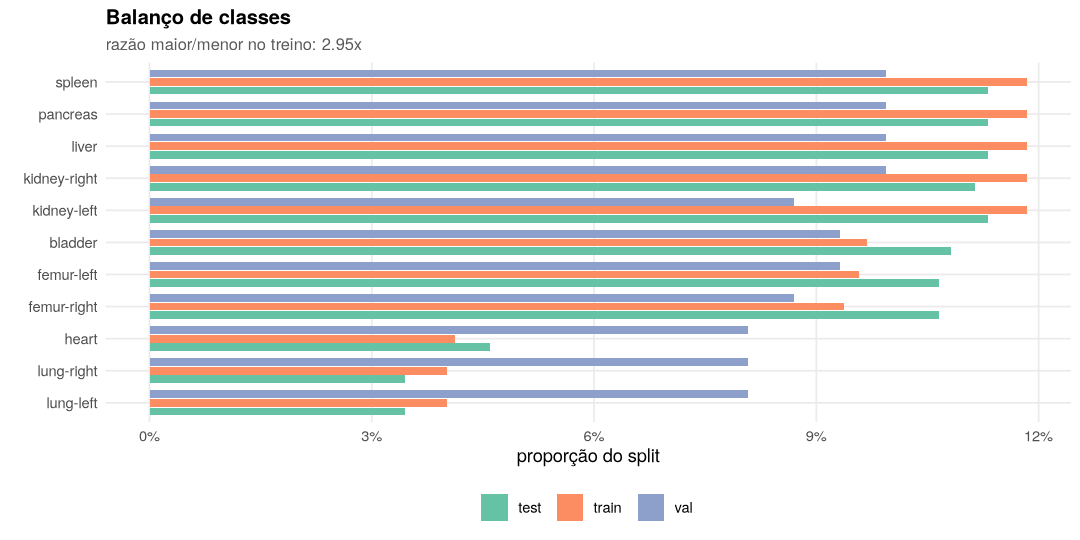

In [4]:
plot_class_balance(eda)

In [5]:
cat(sprintf("razão maior/menor: %.2fx\n", s$train_imbalance_ratio))

razão maior/menor: 2.95x


## As imagens

Um volume 28³ não é PNG. Cada painel é o **desvio ao longo da profundidade**:
realça onde o volume muda entre fatias, que é a informação que uma fatia sozinha
não tem.

Outras reduções, via `eda.volume_view`:

| modo | leitura | tamanho |
|---|---|---|
| `std` | textura da variação entre fatias | 252 KB |
| `mean` | média das fatias, suave | 144 KB |
| `triplanar` | três projeções ortogonais | 392 KB |
| `mosaic` | as 28 fatias em grade; preserva tudo | 4,7 MB |
| `middle` | fatia central | 208 KB |
| `mip` | máximo; satura em TC, o osso lava a imagem | 176 KB |


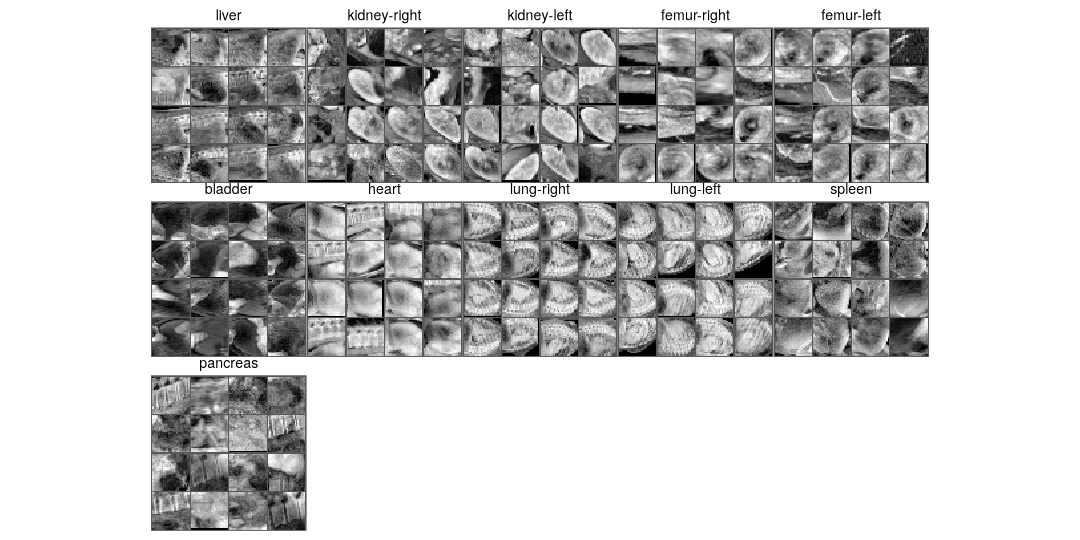

In [6]:
montage_grid(eda, root = RAIZ)

## Estatística de pixel

Calculada sobre o volume inteiro, as 28 fatias.

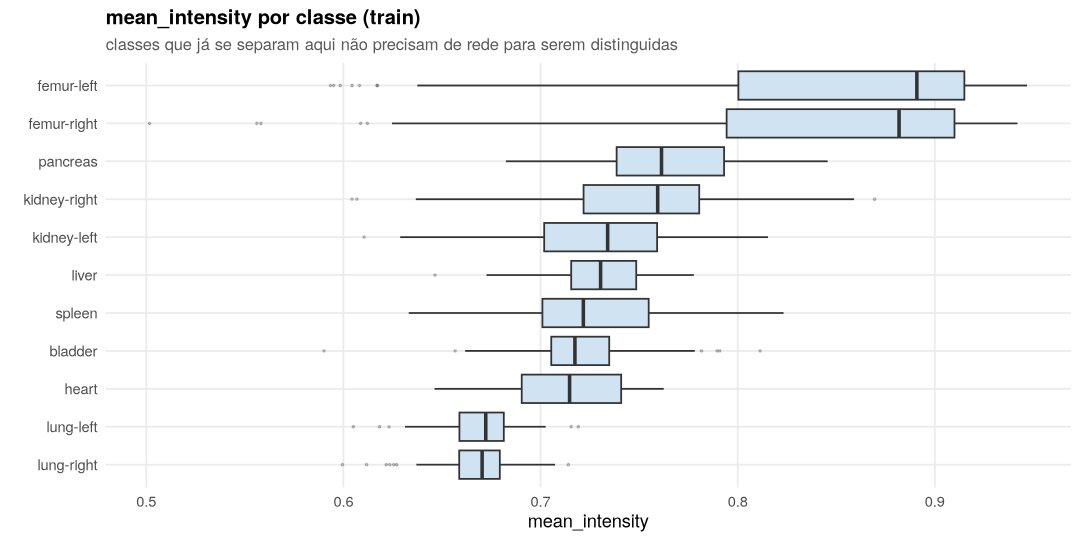

In [7]:
plot_feature_by_class(eda, "mean_intensity", "train")

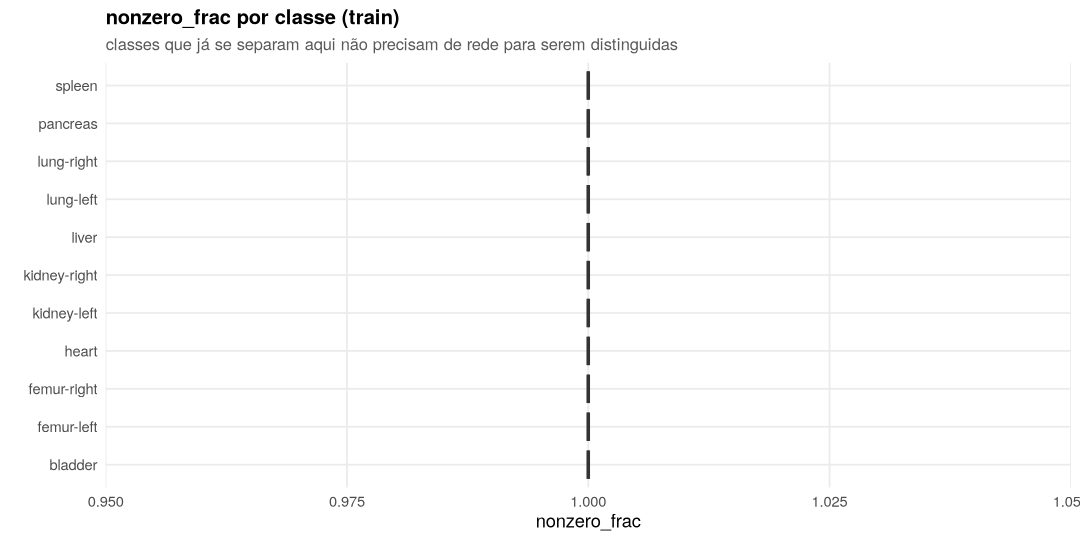

In [8]:
plot_feature_by_class(eda, "nonzero_frac", "train")

In [9]:
treino <- filter(eda$examples, split == "train")
r2 <- sapply(c("mean_intensity", "std_intensity", "nonzero_frac"), function(v)
  summary(lm(as.formula(paste(v, "~ factor(class_name)")), data = treino))$r.squared)
round(r2, 3)

Warning message in summary.lm(lm(as.formula(paste(v, "~ factor(class_name)")), data = treino)):
“ajuste essencialmente perfeito: resumo (summary) pode não ser confiável”


mean_intensity  std_intensity   nonzero_frac 
         0.441          0.620          0.498

## Comparabilidade entre splits

In [10]:
eda$examples |>
  group_by(split) |>
  summarise(n = n(), across(c(mean_intensity, std_intensity, nonzero_frac), mean), .groups = "drop") |>
  as.data.frame()

split,n,mean_intensity,std_intensity,nonzero_frac
<chr>,<int>,<dbl>,<dbl>,<dbl>
test,610,0.7408135,0.1111119,1
train,971,0.7504605,0.1160259,1
val,161,0.7606712,0.1189334,1


## Limitações do tratamento por canais

- A ordem das fatias é ignorada: permutá-las daria o mesmo resultado.
- Augmentation espacial está desligada; as ops do torchvision operam em 2D.
- Comparação com a literatura 3D não é válida: o modelo é outro.